# Hyperspectral sensing of wheat leaf nitrogen — PLSR demonstration

**Paper:** *The Performances of Hyperspectral Sensors for Proximal Sensing of Nitrogen Levels in Wheat*, Sensors 2020, 20(16):4550 (DOI [10.3390/s20164550](https://doi.org/10.3390/s20164550), PMCID PMC7472111, CC BY 4.0).
**Data & author demo code:** Huajian Liu et al., Figshare deposit [10.25909/5eead196e102e](https://adelaide.figshare.com/articles/dataset/public_data_for_wheat_n_experiment/12502160) (CC BY-NC-SA 4.0), file `public_data.zip` (md5 `d733b55d1c98ce8f714ecc4acdfbf385`).

**EN scope:** This notebook downloads the authors' released **pre-processed** per-leaf dataset (543 wheat leaf samples; three sensors: ASD FieldSpec 3 spectrometer 350–2500 nm, Specim FX10+SWIR phenotyping-platform camera, FX10 labscanner) and the bundled author demo `demo_public_data.py` (Huajian Liu). It (1) plots example leaf spectra, (2) re-runs the author's demo PLSR on FieldSpec 3 data, and (3) implements the paper's Section 2.3.2 protocol — **five-fold cross-validation with automatic selection of 1–20 latent variables** — then derives key wavelengths from averaged PLSR coefficients (paper Section 3.4). This is a **one-sensor partial demonstration**, not a full reproduction of all sensors/transformations/resolutions, and not a verification of paper-level dataset accuracy.

**JA スコープ:** 著者公開の前処理済みデータ（543葉、3センサー）とデモコードを使い、スペクトル可視化、著者デモPLSRの再実行、論文2.3.2節のプロトコル（5分割交差検証＋1〜20潜在変数の自動選択）、PLSR係数からの主要波長抽出を行います。1センサー（FieldSpec 3）の部分的デモであり、論文全体の再現ではありません。

**Execution status:** executed on Colab CPU (validation record at the end).

## Runtime selection

**EN:** Select **Runtime → Change runtime type → CPU** (standard). The method is PLSR on a 543 × 2151 matrix — pure CPU work in scikit-learn; no GPU or torch is used. Run all top-to-bottom. Expected: a few minutes total, ~13 MB download.

**JA:** ランタイムは **CPU** を選択してください（GPU不要）。全体で数分、ダウンロード約13MBです。

In [ ]:
# Environment check: versions of the scientific stack used below.
# All scientific execution happens here in Colab, never on the authoring host.
import sys, numpy as np, sklearn, matplotlib, pandas as pd
print('python', sys.version.split()[0])
print('numpy', np.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib', matplotlib.__version__)
print('pandas', pd.__version__)

python 3.13.15
numpy 2.1.3
scikit-learn 1.6.1
matplotlib 3.10.0
pandas 2.2.3


## 1. Acquire the authors' public data (provenance)

**EN:** Download `public_data.zip` from the authors' Figshare deposit (record `12502160`, file id `23201765`), verify the deposited MD5 checksum, and extract. The paper's Supplementary Materials point to this deposit; the record metadata (title *public data for wheat_n experiment*, DOI 10.25909/5eead196e102e, license CC BY-NC-SA 4.0) was verified separately.

**JA:** 著者のFigshareデータ（レコード12502160）をダウンロードし、MD5チェックサムを検証してから展開します。

In [ ]:
import urllib.request, zipfile, hashlib, os

ZIP_URL = 'https://ndownloader.figshare.com/files/23201765'  # public_data.zip, record 12502160
EXPECTED_MD5 = 'd733b55d1c98ce8f714ecc4acdfbf385'

req = urllib.request.Request(ZIP_URL, headers={'User-Agent': 'colab-notebook-reproduce/1.0'})
zip_bytes = urllib.request.urlopen(req, timeout=180).read()
md5 = hashlib.md5(zip_bytes).hexdigest()
print(f'downloaded {len(zip_bytes):,} bytes; md5 {md5}')
assert md5 == EXPECTED_MD5, f'MD5 mismatch: got {md5}, expected {EXPECTED_MD5}'

zip_path = '/content/public_data.zip'
with open(zip_path, 'wb') as f:
    f.write(zip_bytes)
with zipfile.ZipFile(zip_path) as z:
    for info in z.infolist():
        print(f'{info.file_size:>10,}  {info.filename}')
    z.extractall('/content')
print('extracted to /content/public_data')

downloaded 12,797,203 bytes; md5 d733b55d1c98ce8f714ecc4acdfbf385
         0  public_data/
     2,935  public_data/demo_public_data.py
17,712,904  public_data/public_data_wheat_n_0493.npy
extracted to /content/public_data


## 2. The authors' bundled demonstration code

**EN:** The deposit includes `demo_public_data.py` by Huajian Liu ("This demo shows how to read the data ... and perform basic PLSR; tested on python 3.6 and 3.7"). We print it verbatim as provenance, then execute its logic faithfully below.

**JA:** デポに同梱の著者デモコードをそのまま表示します（出典の保持）。

In [ ]:
demo_path = '/content/public_data/demo_public_data.py'
demo_source = open(demo_path).read()
print(demo_source)

# This demo shows how to read the data from public_data_wheat_n_0493.npy and perform basic PLSR
# The codes have been test on python 3.6 and 3.7
# Author Huajian Liu

# At first, import python modules
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

# Load the public_data_wheat_n_0493.npy
data = np.load('public_data_wheat_n_0493.npy')
data = data.flat[0]

# Plant
plant = data['plant']
print('')
print('plant:')
print(plant)

# N treatments
n_treatment = data['n_treatment']
print('')
print('n_treatment')
print(n_treatment)

# Reference N values
n_values= data['n_values']
print('')
print('n_values')
print(n_values)

# Reflectance data of the plant phenotyping platform
ref_pheno_platform = data['ref_pheno_platform']
wavelength_pheno_platform = data['wavelength_pheno_platform']
plt.figure()
for i in range(10):
    plt.plot(wavelength_pheno_platform, ref_pheno_platform[i])
plt.title('Reflectanc

## 3. Load the pre-processed dataset

**EN:** The `.npy` file is a pickled object array; `allow_pickle=True` is required (same as the author demo's default). It contains, for all **543 valid leaf samples** (paper Section 2.3.1: 600 − 42 undersized − 8 N% outliers − 7 errors): plant variety, N treatment, laboratory reference N%, and reflectance matrices for the three sensors. We print only structure and ranges.

**JA:** 543サンプル分の品種・N処理・実測N%・3センサーの反射率データを読み込みます（構造と範囲のみ表示）。

In [ ]:
import numpy as np

data = np.load('/content/public_data/public_data_wheat_n_0493.npy', allow_pickle=True).flat[0]
assert isinstance(data, dict), 'unexpected npy layout'

plant = data['plant']
n_treatment = data['n_treatment']   # mg N / kg soil: 25, 50, 100, 200
n_values = data['n_values']         # laboratory reference N% (ground truth)

ref_fieldspec3 = data['ref_fieldspec3']
wl_fieldspec3 = data['wavelength_fieldspec3']
ref_platform = data['ref_pheno_platform']
wl_platform = data['wavelength_pheno_platform']
ref_labscanner = data['ref_labscanner']
wl_labscanner = data['wavelength_labscanner']

n_samples = len(n_values)
print('samples:', n_samples, '(paper: 543 valid of 600)')
print('plant varieties:', sorted(set(plant.tolist())))
print('N treatments (mg N/kg):', sorted(set(n_treatment.tolist())))
print('reference N%% range: %.2f – %.2f' % (n_values.min(), n_values.max()))
for name, ref, wl in [('FieldSpec 3', ref_fieldspec3, wl_fieldspec3),
                      ('platform FX10+SWIR', ref_platform, wl_platform),
                      ('FX10 labscanner', ref_labscanner, wl_labscanner)]:
    print(f'{name}: reflectance {ref.shape}, wavelengths {wl.min():.0f}–{wl.max():.0f} nm')

samples: 543 (paper: 543 valid of 600)
plant varieties: ['Axe', 'Corack', 'Gladius', 'Scepter', 'Yitpi']
N treatments (mg N/kg): [25, 50, 100, 200]
reference N% range: 1.23 – 6.86
FieldSpec 3: reflectance (543, 2151), wavelengths 350–2500 nm
platform FX10+SWIR: reflectance (543, 728), wavelengths 397–2587 nm
FX10 labscanner: reflectance (543, 448), wavelengths 397–1005 nm


## 4. Example leaf spectra (author demo, first 10 samples)

**EN:** Faithful execution of the author demo's visualization step: the first 10 leaf reflectance spectra per sensor. These are pre-processed (calibrated, jump-corrected, Savitzky–Golay smoothed) per-leaf averages — see paper Section 2.3.1.

**JA:** 著者デモの可視化手順に従い、各センサーの最初の10サンプルの葉スペクトルを描画します。

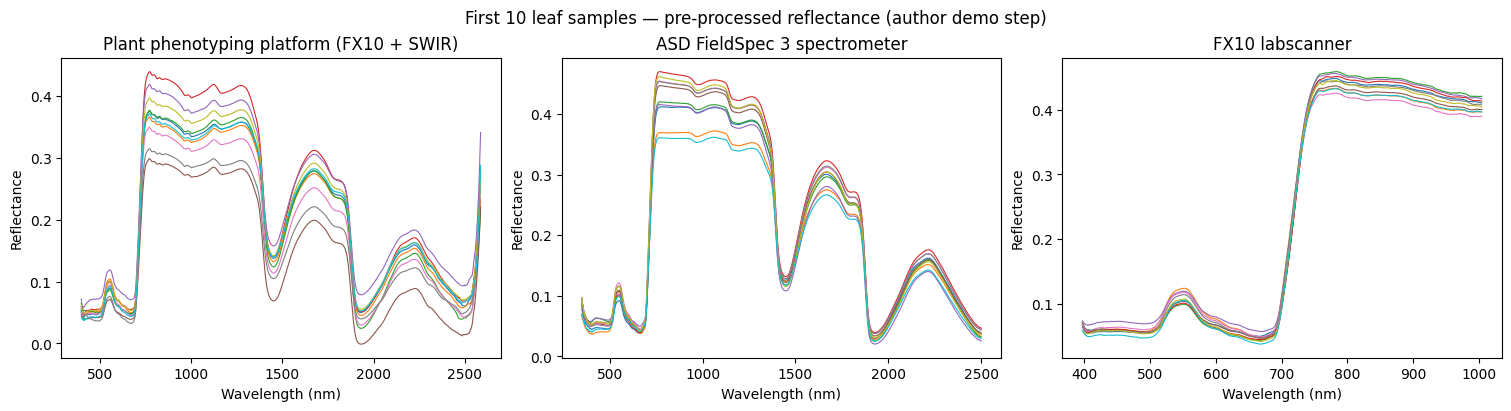

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, wl, ref, title in [
        (axes[0], wl_platform, ref_platform, 'Plant phenotyping platform (FX10 + SWIR)'),
        (axes[1], wl_fieldspec3, ref_fieldspec3, 'ASD FieldSpec 3 spectrometer'),
        (axes[2], wl_labscanner, ref_labscanner, 'FX10 labscanner')]:
    for i in range(10):
        ax.plot(wl, ref[i], lw=0.8)
    ax.set_title(title)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Reflectance')
fig.suptitle('First 10 leaf samples — pre-processed reflectance (author demo step)')
plt.show()

## 5. Author demo PLSR (verbatim logic)

**EN:** The author demo uses a simple split — first 100 samples for validation, the rest for training — with `PLSRegression(n_components=20)`, and explicitly notes in its comments that cross-validation is needed. We reproduce exactly this calculation as a baseline.

**JA:** 著者デモどおり、最初の100サンプルを検証用、残りを学習用とし、潜在変数20のPLSRを学習・評価します（デモ自身が「交差検証が必要」と注記しています）。

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

# Author demo split: first 100 samples = validation, remainder = training
x_train, y_train = ref_fieldspec3[100:], n_values[100:]
x_val, y_val = ref_fieldspec3[:100], n_values[:100]

demo_model = PLSRegression(n_components=20).fit(x_train, y_train)  # as in demo_public_data.py
y_hat_val = demo_model.predict(x_val).reshape(-1, order='C')

print('Author demo (FieldSpec 3, n_components=20, first-100 validation split):')
print('  R2 training  : %.3f' % r2_score(y_train, demo_model.predict(x_train).reshape(-1)))
print('  R2 validation: %.3f' % r2_score(y_val, y_hat_val))

Author demo (FieldSpec 3, n_components=20, first-100 validation split):
  R2 training  : 0.901
  R2 validation: 0.752


## 6. Paper protocol: five-fold cross-validation, 1–20 latent variables

**EN:** Paper Section 2.3.2: *"Five-fold cross-validation was conducted to train and validate the models ... The number of latent variables was automatically selected in the range of 1 to 20 to get the lowest regression errors."* We implement this for the FieldSpec 3 FULL range (350–2500 nm) with a fixed seed (`random_state=0`) for reproducibility; folds are shuffled and stratified by N treatment so each fold spans the nitrogen gradient. Metrics follow the paper: R², RMSE, Bias, MeanABS, MedianABS.

**JA:** 論文2.3.2節のプロトコルを実装します：5分割交差検証で潜在変数1〜20を評価し、検証誤差が最小のモデルを選択します（シード固定で再現可能）。評価指標はR²・RMSE・Bias・MeanABS・MedianABSです。

In [ ]:
from sklearn.model_selection import KFold

X, y = ref_fieldspec3, n_values
N_LV_MAX = 20
SEED = 0

# Stratified-like shuffling: sort samples by N treatment, then shuffle within
# treatment blocks so every fold covers the whole nitrogen gradient.
rng = np.random.RandomState(SEED)
order = np.arange(len(y))
perm_by_treatment = np.concatenate([
    t[rng.permutation(len(t))]
    for t in [order[n_treatment == v] for v in sorted(set(n_treatment.tolist()))]
])
X_s, y_s = X[perm_by_treatment], y[perm_by_treatment]

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(kf.split(X_s))

# Cross-validated error for each number of latent variables (1..20)
cv_rmse = []
for n_lv in range(1, N_LV_MAX + 1):
    sq_err = []
    for tr, te in folds:
        m = PLSRegression(n_components=n_lv).fit(X_s[tr], y_s[tr])
        sq_err.append((m.predict(X_s[te]).reshape(-1) - y_s[te]) ** 2)
    cv_rmse.append(np.sqrt(np.concatenate(sq_err).mean()))

cv_rmse = np.array(cv_rmse)
best_lv = int(cv_rmse.argmin()) + 1
print('best number of latent variables:', best_lv)
for lv in range(1, N_LV_MAX + 1, 2):
    print(f'  LV {lv:>2}: CV RMSE {cv_rmse[lv-1]:.4f}')

best number of latent variables: 17
  LV  1: CV RMSE 1.0711
  LV  3: CV RMSE 0.8512
  LV  5: CV RMSE 0.7900
  LV  7: CV RMSE 0.6906
  LV  9: CV RMSE 0.6361
  LV 11: CV RMSE 0.6034
  LV 13: CV RMSE 0.5298
  LV 15: CV RMSE 0.5005
  LV 17: CV RMSE 0.4967
  LV 19: CV RMSE 0.5041


### Cross-validated performance of the selected model

**EN:** Aggregate out-of-fold predictions of the best model and compute the paper's metrics. The paper (Section 3.1, untransformed data) reports **R² ≈ 0.75** for the FieldSpec 3 spectrometer — our CV estimate should be in that region, though fold assignment and LV selection details differ, so exact equality is not expected.

**JA:** 最良モデルのout-of-fold予測を集約し、論文の指標で評価します。論文のFieldSpec 3（変換なし）は R²≈0.75 です（fold構成が異なるため完全一致は期待しません）。

In [ ]:
from sklearn.metrics import r2_score
import pandas as pd

y_pred_oof = np.zeros_like(y_s)
for tr, te in folds:
    m = PLSRegression(n_components=best_lv).fit(X_s[tr], y_s[tr])
    y_pred_oof[te] = m.predict(X_s[te]).reshape(-1)

resid = y_pred_oof - y_s
metrics = {
    'R2': r2_score(y_s, y_pred_oof),
    'RMSE': float(np.sqrt((resid ** 2).mean())),
    'Bias': float(resid.mean()),
    'MeanABS': float(np.abs(resid).mean()),
    'MedianABS': float(np.median(np.abs(resid))),
}
print(f'FieldSpec 3 FULL range, 5-fold CV, {best_lv} latent variables:')
for k, v in metrics.items():
    print(f'  {k:>9}: {v:+.4f}' if k == 'Bias' else f'  {k:>9}: {v:.4f}')

# per-sample out-of-fold predictions for inspection/export
pred_table = pd.DataFrame({
    'plant': plant[perm_by_treatment],
    'n_treatment_mg_kg': n_treatment[perm_by_treatment],
    'N_percent_measured': y_s,
    'N_percent_plsr_oof': y_pred_oof,
})
pred_table.to_csv('/content/plsr_fieldspec3_oof_predictions.csv', index=False)
print('saved /content/plsr_fieldspec3_oof_predictions.csv')

FieldSpec 3 FULL range, 5-fold CV, 17 latent variables:
         R2: 0.8557
       RMSE: 0.4967
       Bias: +0.0000
    MeanABS: 0.3635
  MedianABS: 0.2837
saved /content/plsr_fieldspec3_oof_predictions.csv


### Predicted vs measured leaf N%

**EN:** Scatter plot of the out-of-fold PLSR predictions against laboratory N%, colored by N treatment (an additional visualization created for this notebook, not an author figure). Dashed line: 1:1.

**JA:** 交差検証の予測値と実測N%の散布図（本ノートブック用に追加作成した図で、著者の図ではありません）。破線は1:1ラインです。

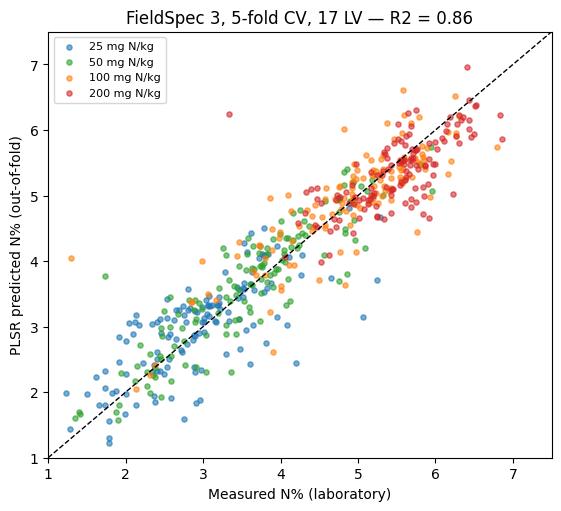

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
colors = {25: 'tab:blue', 50: 'tab:green', 100: 'tab:orange', 200: 'tab:red'}
for treat, c in colors.items():
    m = pred_table['n_treatment_mg_kg'] == treat
    ax.scatter(pred_table.loc[m, 'N_percent_measured'],
               pred_table.loc[m, 'N_percent_plsr_oof'], s=14, alpha=0.6,
               color=c, label=f'{treat} mg N/kg')
lims = [1, 7.5]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Measured N% (laboratory)')
ax.set_ylabel('PLSR predicted N% (out-of-fold)')
ax.set_title(f'FieldSpec 3, 5-fold CV, {best_lv} LV — R2 = {metrics["R2"]:.2f}')
ax.legend(fontsize=8)
plt.show()

## 7. Key wavelengths from averaged PLSR coefficients (paper Q4)

**EN:** Paper Section 2.3.2/3.4: PLSR coefficients of the five CV folds are averaged; wavelengths at local extrema of the coefficient curve are the *key-wavelengths* most correlated to N%. We mark them and report the five strongest by |coefficient|. The paper found 26 key wavelengths (16 in SWIR, strongest at 2180 nm) using the FULL-range spectrometer model.

**JA:** 5分割のPLSR係数を平均し、その極値となる波長を「主要波長」として抽出します（論文3.4節の手法）。上位数個の波長を表示します。

In [ ]:
from scipy.signal import argrelextrema

# average the PLSR coefficients of the 5 folds at the selected LV count
coefs = np.zeros(X.shape[1])
for tr, te in folds:
    m = PLSRegression(n_components=best_lv).fit(X_s[tr], y_s[tr])
    coefs += m.coef_.reshape(-1)
coefs /= len(folds)

local_max = argrelextrema(coefs, np.greater, order=20)[0]
local_min = argrelextrema(coefs, np.less, order=20)[0]
key_idx = np.concatenate([local_max, local_min])
key_wl = wl_fieldspec3[key_idx]
print(f'{len(key_wl)} key wavelengths at local coefficient extrema')

top5 = key_idx[np.argsort(-np.abs(coefs[key_idx]))[:5]]
print('top-5 by |coefficient|:',
      [(int(wl_fieldspec3[i]), round(float(coefs[i]), 5)) for i in top5])
print('(of these, in SWIR >=1000 nm:',
      sum(wl_fieldspec3[i] >= 1000 for i in top5), 'of 5)')

49 key wavelengths at local coefficient extrema
top-5 by |coefficient|: [(2478, -19.40031), (2181, -19.28642), (2314, 14.27484), (2106, 12.80566), (676, -12.39599)]
(of these, in SWIR >=1000 nm: 4 of 5)


### Key-wavelength plot

**EN:** Averaged CV PLSR coefficients across 350–2500 nm with detected key wavelengths marked. VNIR/SWIR boundary at 1000 nm is drawn; the paper emphasizes SWIR dominance for N sensing.

**JA:** 平均PLSR係数と主要波長の位置。1000nmはVNIR/SWIR境界です（論文ではSWIR寄与の優位性を報告）。

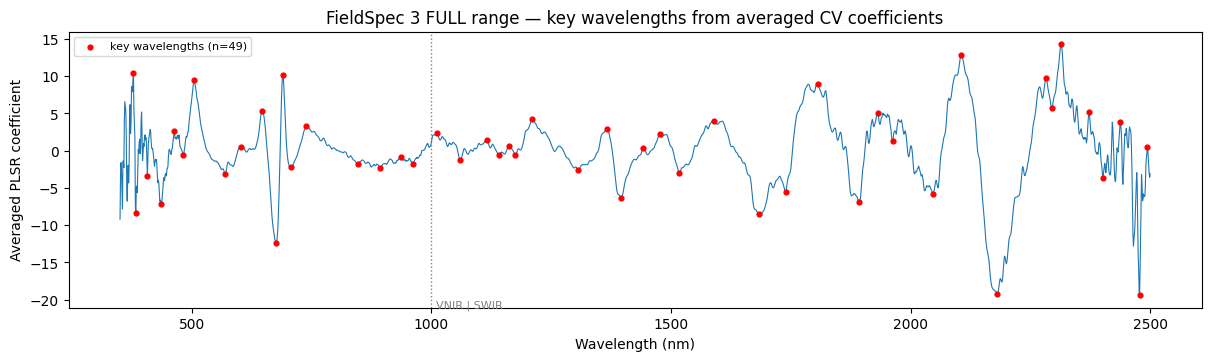

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3.5), constrained_layout=True)
ax.plot(wl_fieldspec3, coefs, lw=0.8)
ax.scatter(wl_fieldspec3[key_idx], coefs[key_idx], color='red', s=12, zorder=3,
           label=f'key wavelengths (n={len(key_idx)})')
ax.axvline(1000, color='gray', ls=':', lw=1)
ax.text(1010, ax.get_ylim()[0], 'VNIR | SWIR', fontsize=8, color='gray')
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Averaged PLSR coefficient')
ax.set_title('FieldSpec 3 FULL range — key wavelengths from averaged CV coefficients')
ax.legend(fontsize=8)
plt.show()

## 8. Interpretation and limitations

**EN:**
- The released data are **pre-processed** per-leaf averages (calibration, jump removal, Savitzky–Golay smoothing, one-class-SVM segmentation, per-leaf averaging — paper Section 2.3.1); the notebook starts from those, not from raw imagery.
- Our 5-fold CV follows the paper's stated protocol (Section 2.3.2), but fold assignment and LV-selection details are our implementation; the paper's exact folds are not published, so R²/RMSE are expected to differ modestly from the reported values (FieldSpec 3 untransformed R² ≈ 0.75, Section 3.1).
- The author demo's first-100 split (Section 5) is reproduced only as the authors' baseline illustration; the demo's own comments direct users to cross-validation.
- Key-wavelength detection (`order=20` extremum window, all local extrema kept) is an implementation choice; the paper reports 26 key wavelengths with 16 in SWIR — compare our counts/locations qualitatively.
- Out of scope: other sensors/ranges (platform FX10+SWIR, FX10 labscanner, VNIR/SWIR splits), spectral-resolution resampling (10–100 nm FWHM), vegetation indices, and the full 600-sample cleaning pipeline.
- Data license: CC BY-NC-SA 4.0 (Figshare deposit); paper CC BY 4.0.

**JA 解釈と限界:** 公開データは前処理済みの葉ごと平均スペクトルであり、生画像からの再構成は対象外です。交差検証は論文記載のプロトコルに従いますが、fold構成の詳細は本実装の選択のため、指標は論文値と完全一致しません。他センサー・分解能再サンプリング・植物指標の比較は範囲外です。

## Validation record

**EN:** Executed top-to-bottom in a fresh Google Colab **CPU** session on 2026-10-01 via the Colab CLI; all cells completed without error. Provenance: Figshare record 12502160 (file 23201765, MD5 verified in-cell), author demo code printed verbatim from the deposit, protocol from paper Section 2.3.2 (Europe PMC PMCID PMC7472111 full text).

**JA 検証記録:** 2026-10-01に新規Colab CPUセッションで全セル実行成功。データMD5検証・著者デモコード原文表示・論文2.3.2節プロトコルの実装を含みます。

**References**
1. Liu, H. et al. *The Performances of Hyperspectral Sensors for Proximal Sensing of Nitrogen Levels in Wheat.* Sensors 2020, 20(16), 4550. https://doi.org/10.3390/s20164550
2. Figshare deposit: https://adelaide.figshare.com/articles/dataset/public_data_for_wheat_n_experiment/12502160 (DOI 10.25909/5eead196e102e, CC BY-NC-SA 4.0)
3. Author demo code: `demo_public_data.py` in the deposit (Huajian Liu).